# Story 1: Infrastructure Investment & Jobs Act Funding Allocation

**Author:** Muhammad Suffyan Khan  
**Course:** DATA 608 - Knowledge and Visual Analytics  
**Funding data:** As of March 2023  

## Story Request

This analysis examines the present allocation of Infrastructure Investment and Jobs Act funding across U.S. states and territories.

The story addresses two questions:

1. Is the allocation equitable based on the population of each state and territory, or is apparent bias present?
2. Does the allocation appear to favor the political interests of the Biden administration?

## Analytical Scope

- Compare funding with jurisdiction population.
- Calculate funding per resident and allocation share versus population share.
- Identify jurisdictions receiving disproportionately high or low allocations.
- Compare states won by Joe Biden and Donald Trump in the 2020 presidential election.
- Treat territories separately in the political analysis because they did not participate in the presidential general election.
- Treat Tribal Communities separately because they overlap state and territory populations.

The analysis identifies statistical patterns and does not infer political motivation without supporting evidence.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display and chart settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid")

# Locate the Story 1 folder regardless of the notebook working directory
current_directory = Path.cwd().resolve()

if (current_directory / "story_01_iija").exists():
    story_directory = current_directory / "story_01_iija"
elif current_directory.name == "notebooks":
    story_directory = current_directory.parent
else:
    raise FileNotFoundError(
        "The story_01_iija folder could not be located from the current directory."
    )

raw_file = (
    story_directory
    / "data"
    / "raw"
    / "IIJA FUNDING AS OF MARCH 2023.xlsx"
)

if not raw_file.exists():
    raise FileNotFoundError(f"Funding workbook not found: {raw_file}")

funding_raw = pd.read_excel(raw_file)

print(f"Python executable: {sys.executable}")
print(f"Workbook: {raw_file}")
print(f"Dataset shape: {funding_raw.shape}")
print(f"Columns: {funding_raw.columns.tolist()}")

display(funding_raw.head())

Python executable: c:\Users\offcs\anaconda3\envs\data608\python.exe
Workbook: C:\Users\offcs\GitHub\DATA608-Knowledge-Visual-Analytics\story_01_iija\data\raw\IIJA FUNDING AS OF MARCH 2023.xlsx
Dataset shape: (57, 2)
Columns: ['State, Teritory or Tribal Nation', 'Total (Billions)']


,"State, Teritory or Tribal Nation",Total (Billions)
0,ALABAMA,3.0000
1,ALASKA,3.7000
2,AMERICAN SAMOA,0.0686
3,ARIZONA,3.5000
4,ARKANSAS,2.8000


## 1. Funding Data Audit and Preparation

The professor-provided workbook contains funding allocations for 57 rows: the 50 states, the District of Columbia, five U.S. territories, and Tribal Communities.

The original workbook remains unchanged. Cleaning is performed on a separate DataFrame. The following corrections and classifications are documented:

- Standardize column names.
- Correct `DELEWARE` to `DELAWARE`.
- Classify states and D.C., territories, and Tribal Communities separately.
- Convert funding from billions of dollars into dollars.
- Check missing values, duplicate jurisdictions, and invalid funding amounts.

In [2]:
# Create a working copy without modifying the original data
funding = funding_raw.copy()

# Standardize column names
funding = funding.rename(
    columns={
        "State, Teritory or Tribal Nation": "jurisdiction",
        "Total (Billions)": "funding_billions",
    }
)

# Standardize jurisdiction names
funding["jurisdiction"] = (
    funding["jurisdiction"]
    .astype(str)
    .str.strip()
    .str.upper()
    .replace({"DELEWARE": "DELAWARE"})
)

# Identify jurisdiction types
territories = {
    "AMERICAN SAMOA",
    "GUAM",
    "NORTHERN MARIANA ISLANDS",
    "PUERTO RICO",
    "US VIRGIN ISLANDS",
}

funding["jurisdiction_type"] = np.select(
    [
        funding["jurisdiction"].eq("TRIBAL COMMUNITIES"),
        funding["jurisdiction"].isin(territories),
    ],
    [
        "Tribal Communities",
        "Territory",
    ],
    default="State or District of Columbia",
)

# Convert billions to dollars
funding["funding_dollars"] = funding["funding_billions"] * 1_000_000_000

# Data-quality checks
audit_summary = pd.Series(
    {
        "Rows": len(funding),
        "Columns": len(funding.columns),
        "Missing values": int(funding.isna().sum().sum()),
        "Duplicate jurisdictions": int(funding["jurisdiction"].duplicated().sum()),
        "Nonpositive funding amounts": int((funding["funding_billions"] <= 0).sum()),
        "Total funding (billions)": funding["funding_billions"].sum(),
    },
    name="Result",
)

display(audit_summary.to_frame())
display(
    funding["jurisdiction_type"]
    .value_counts()
    .rename_axis("Jurisdiction type")
    .to_frame("Count")
)

funding.head()

,Result
Rows,57.0000
Columns,4.0000
Missing values,0.0000
Duplicate jurisdictions,0.0000
Nonpositive funding amounts,0.0000
Total funding (billions),196.0324


,Count
Jurisdiction type,
State or District of Columbia,51
Territory,5
Tribal Communities,1


,jurisdiction,funding_billions,jurisdiction_type,funding_dollars
0,ALABAMA,3.0000,State or District of Columbia,"3,000,000,000.0000"
1,ALASKA,3.7000,State or District of Columbia,"3,700,000,000.0000"
2,AMERICAN SAMOA,0.0686,Territory,"68,600,000.0000"
3,ARIZONA,3.5000,State or District of Columbia,"3,500,000,000.0000"
4,ARKANSAS,2.8000,State or District of Columbia,"2,800,000,000.0000"


## 2. Population Data

Population should correspond as closely as possible to the March 2023 funding snapshot.

- July 1, 2022 population estimates are used for the 50 states, the District of Columbia, and Puerto Rico.
- Official 2020 Census counts are used for American Samoa, Guam, the Northern Mariana Islands, and the U.S. Virgin Islands because those Island Areas are not included in the same annual state estimates table.
- Population years are retained in the dataset and disclosed as a limitation.

**Sources**

- U.S. Census Bureau, *Annual Estimates of the Resident Population: April 1, 2020 to July 1, 2022*, table NST-EST2022-POP.
- U.S. Census Bureau, *2020 Population of U.S. Island Areas*.

In [3]:
import requests

external_directory = story_directory / "data" / "external"
external_directory.mkdir(parents=True, exist_ok=True)

population_url = (
    "https://www2.census.gov/programs-surveys/popest/"
    "tables/2020-2022/state/totals/NST-EST2022-POP.xlsx"
)

population_file = external_directory / "NST-EST2022-POP.xlsx"

# Download and preserve the official Census workbook
if not population_file.exists():
    response = requests.get(population_url, timeout=60)
    response.raise_for_status()
    population_file.write_bytes(response.content)

print(f"Population workbook saved to: {population_file}")

Population workbook saved to: C:\Users\offcs\GitHub\DATA608-Knowledge-Visual-Analytics\story_01_iija\data\external\NST-EST2022-POP.xlsx


In [4]:
# Read the official 2022 Census population estimates
population_workbook = pd.read_excel(population_file, header=3)

population_2022 = population_workbook.iloc[:, [0, 4]].copy()
population_2022.columns = ["jurisdiction", "population"]

# Official jurisdiction rows begin with a leading period
population_2022 = population_2022[
    population_2022["jurisdiction"].astype(str).str.startswith(".")
].copy()

population_2022["jurisdiction"] = (
    population_2022["jurisdiction"]
    .str.lstrip(".")
    .str.strip()
    .str.upper()
)

population_2022["population"] = (
    pd.to_numeric(population_2022["population"], errors="coerce")
    .astype("Int64")
)

population_2022["population_year"] = 2022
population_2022["population_source"] = (
    "U.S. Census Bureau, NST-EST2022-POP"
)

# Official 2020 Census counts for the four Island Areas
island_population_2020 = pd.DataFrame(
    {
        "jurisdiction": [
            "AMERICAN SAMOA",
            "GUAM",
            "NORTHERN MARIANA ISLANDS",
            "US VIRGIN ISLANDS",
        ],
        "population": [
            49_710,
            153_836,
            47_329,
            87_146,
        ],
        "population_year": [2020, 2020, 2020, 2020],
        "population_source": [
            "U.S. Census Bureau, 2020 Island Areas Census"
        ] * 4,
    }
)

population = pd.concat(
    [population_2022, island_population_2020],
    ignore_index=True,
)

# Population-data audit
print(f"Population rows: {len(population)}")
print(f"Duplicate jurisdictions: {population['jurisdiction'].duplicated().sum()}")
print(f"Missing population values: {population['population'].isna().sum()}")

display(
    population["population_year"]
    .value_counts()
    .sort_index()
    .rename_axis("Population year")
    .to_frame("Jurisdictions")
)

display(population.head())

Population rows: 56
Duplicate jurisdictions: 0
Missing population values: 0


,Jurisdictions
Population year,
2020,4
2022,52


,jurisdiction,population,population_year,population_source
0,ALABAMA,5074296,2022,"U.S. Census Bureau, NST-EST2022-POP"
1,ALASKA,733583,2022,"U.S. Census Bureau, NST-EST2022-POP"
2,ARIZONA,7359197,2022,"U.S. Census Bureau, NST-EST2022-POP"
3,ARKANSAS,3045637,2022,"U.S. Census Bureau, NST-EST2022-POP"
4,CALIFORNIA,39029342,2022,"U.S. Census Bureau, NST-EST2022-POP"


## 3. Population-Adjusted Funding Measures

Population and funding data are merged using standardized jurisdiction names.

The following measures are calculated:

- **Funding per resident:** allocation divided by population.
- **Population share:** jurisdiction population divided by the combined population.
- **Funding share:** jurisdiction funding divided by combined geographic funding.
- **Expected proportional funding:** funding expected if the geographic total were distributed strictly according to population.
- **Allocation ratio:** funding share divided by population share.

An allocation ratio of:

- `1.00` represents exact population proportionality.
- Greater than `1.00` represents more funding than a strictly population-based allocation.
- Less than `1.00` represents less funding than a strictly population-based allocation.

The $3 billion Tribal Communities allocation is reported separately because tribal populations overlap state and territory populations.

In [5]:
# Separate geographic jurisdictions from the overlapping Tribal Communities row
geographic_funding = funding[
    funding["jurisdiction_type"] != "Tribal Communities"
].copy()

tribal_funding = funding[
    funding["jurisdiction_type"] == "Tribal Communities"
].copy()

# Verify jurisdiction names before merging
funding_names = set(geographic_funding["jurisdiction"])
population_names = set(population["jurisdiction"])

missing_population = sorted(funding_names - population_names)
unmatched_population = sorted(population_names - funding_names)

print(f"Funding jurisdictions without population data: {missing_population}")
print(f"Population jurisdictions without funding data: {unmatched_population}")

# Require a complete one-to-one match
analysis = geographic_funding.merge(
    population,
    on="jurisdiction",
    how="inner",
    validate="one_to_one",
)

assert len(analysis) == 56
assert not missing_population
assert not unmatched_population

# Geographic totals exclude the overlapping Tribal Communities allocation
total_geographic_funding = analysis["funding_dollars"].sum()
total_geographic_population = analysis["population"].sum()

# Calculate equity measures
analysis["funding_per_resident"] = (
    analysis["funding_dollars"] / analysis["population"]
)

analysis["population_share"] = (
    analysis["population"] / total_geographic_population
)

analysis["funding_share"] = (
    analysis["funding_dollars"] / total_geographic_funding
)

analysis["expected_funding_billions"] = (
    analysis["population_share"]
    * total_geographic_funding
    / 1_000_000_000
)

analysis["allocation_ratio"] = (
    analysis["funding_share"] / analysis["population_share"]
)

analysis["funding_difference_billions"] = (
    analysis["funding_billions"]
    - analysis["expected_funding_billions"]
)

print(f"Matched geographic jurisdictions: {len(analysis)}")
print(
    f"Geographic funding analyzed: "
    f"${total_geographic_funding / 1_000_000_000:,.4f} billion"
)
print(f"Combined population: {total_geographic_population:,.0f}")
print(
    f"Median funding per resident: "
    f"${analysis['funding_per_resident'].median():,.2f}"
)
print(
    f"Tribal Communities reported separately: "
    f"${tribal_funding['funding_billions'].iloc[0]:,.1f} billion"
)

Funding jurisdictions without population data: []
Population jurisdictions without funding data: []
Matched geographic jurisdictions: 56
Geographic funding analyzed: $193.0324 billion
Combined population: 336,847,367
Median funding per resident: $616.98
Tribal Communities reported separately: $3.0 billion


In [6]:
comparison_columns = [
    "jurisdiction",
    "jurisdiction_type",
    "funding_billions",
    "population",
    "funding_per_resident",
    "allocation_ratio",
]

print("Highest funding per resident")
display(
    analysis.nlargest(10, "funding_per_resident")[comparison_columns]
)

print("Lowest funding per resident")
display(
    analysis.nsmallest(10, "funding_per_resident")[comparison_columns]
)

Highest funding per resident


,jurisdiction,jurisdiction_type,funding_billions,population,funding_per_resident,allocation_ratio
1,ALASKA,State or District of Columbia,3.7000,733583,"5,043.7374",8.8015
55,WYOMING,State or District of Columbia,2.3000,581381,"3,956.0976",6.9035
28,MONTANA,State or District of Columbia,3.3000,1122867,"2,938.9055",5.1285
36,NORTH DAKOTA,State or District of Columbia,1.8000,779261,"2,309.8808",4.0308
37,NORTHERN MARIANA ISLANDS,Territory,0.0833,47329,"1,760.0203",3.0713
48,US VIRGIN ISLANDS,Territory,0.1483,87146,"1,701.7419",2.9696
9,DISTRICT OF COLUMBIA,State or District of Columbia,1.1000,671803,"1,637.3848",2.8573
45,SOUTH DAKOTA,State or District of Columbia,1.3000,909824,"1,428.8478",2.4934
2,AMERICAN SAMOA,Territory,0.0686,49710,"1,380.0040",2.4081
50,VERMONT,State or District of Columbia,0.8521,647064,"1,316.8713",2.2980


Lowest funding per resident


,jurisdiction,jurisdiction_type,funding_billions,population,funding_per_resident,allocation_ratio
42,PUERTO RICO,Territory,0.9937,3221789,308.4311,0.5382
10,FLORIDA,State or District of Columbia,8.2000,22244823,368.6251,0.6433
35,NORTH CAROLINA,State or District of Columbia,4.5000,10698973,420.6011,0.7340
44,SOUTH CAROLINA,State or District of Columbia,2.3000,5282634,435.3889,0.7598
22,MARYLAND,State or District of Columbia,2.7000,6164660,437.9804,0.7643
11,GEORGIA,State or District of Columbia,5.0000,10912876,458.1744,0.7995
5,CALIFORNIA,State or District of Columbia,18.4000,39029342,471.4402,0.8227
25,MINNESOTA,State or District of Columbia,2.7000,5717184,472.2605,0.8241
47,TEXAS,State or District of Columbia,14.2000,30029572,472.8672,0.8252
54,WISCONSIN,State or District of Columbia,2.8000,5892539,475.1772,0.8292


## 4. Official 2020 Presidential Election Results

Official state-level election results are sourced from the Federal Election Commission's *Federal Elections 2020* publication.

For this analysis, a jurisdiction is classified according to whether Joe Biden or Donald Trump received more statewide popular votes. The District of Columbia is included. U.S. territories and Tribal Communities are excluded because they did not participate as jurisdictions in the presidential general election.

**Source:** Federal Election Commission, *Federal Elections 2020*  
https://www.fec.gov/introduction-campaign-finance/election-results-and-voting-information/federal-elections-2020/

In [7]:
election_url = (
    "https://www.fec.gov/documents/4228/"
    "federalelections2020.xlsx"
)

election_file = external_directory / "federalelections2020.xlsx"

# Download and preserve the official FEC workbook
if not election_file.exists():
    response = requests.get(election_url, timeout=60)
    response.raise_for_status()
    election_file.write_bytes(response.content)

print(f"Election workbook saved to: {election_file}")

Election workbook saved to: C:\Users\offcs\GitHub\DATA608-Knowledge-Visual-Analytics\story_01_iija\data\external\federalelections2020.xlsx


In [8]:
# Read the FEC state-level presidential summary
election_summary = pd.read_excel(
    election_file,
    sheet_name="3. Table 2 Electoral & Pop Vote",
    header=None,
    skiprows=4,
    nrows=51,
)

election_summary.columns = [
    "state_abbreviation",
    "biden_electoral_votes",
    "trump_electoral_votes",
    "biden_votes",
    "trump_votes",
    "other_votes",
    "total_votes",
]

# Maine and Nebraska have an asterisk because they can split electoral votes
election_summary["state_abbreviation"] = (
    election_summary["state_abbreviation"]
    .astype(str)
    .str.replace("*", "", regex=False)
    .str.strip()
)

# Obtain full jurisdiction names from the detailed FEC results sheet
election_detail = pd.read_excel(
    election_file,
    sheet_name="9. 2020 Pres General Results",
)

state_lookup = (
    election_detail[["STATE", "STATE ABBREVIATION"]]
    .dropna()
    .drop_duplicates()
    .rename(
        columns={
            "STATE": "jurisdiction",
            "STATE ABBREVIATION": "state_abbreviation",
        }
    )
)

state_lookup["jurisdiction"] = (
    state_lookup["jurisdiction"]
    .astype(str)
    .str.strip()
    .str.upper()
)

state_lookup["state_abbreviation"] = (
    state_lookup["state_abbreviation"]
    .astype(str)
    .str.strip()
)

# Join abbreviations to full names
election = election_summary.merge(
    state_lookup,
    on="state_abbreviation",
    how="left",
    validate="one_to_one",
)

# Determine statewide popular-vote winner
election["2020_winner"] = np.where(
    election["biden_votes"] > election["trump_votes"],
    "Biden",
    "Trump",
)

# Two-party vote margin provides additional political context
election["two_party_margin"] = (
    (election["biden_votes"] - election["trump_votes"])
    / (election["biden_votes"] + election["trump_votes"])
)

# Validate the election dataset
print(f"Election jurisdictions: {len(election)}")
print(f"Missing jurisdiction names: {election['jurisdiction'].isna().sum()}")
print(f"Duplicate jurisdictions: {election['jurisdiction'].duplicated().sum()}")

display(
    election["2020_winner"]
    .value_counts()
    .rename_axis("2020 winner")
    .to_frame("Jurisdictions")
)

display(
    election[
        [
            "jurisdiction",
            "state_abbreviation",
            "biden_votes",
            "trump_votes",
            "2020_winner",
            "two_party_margin",
        ]
    ].head()
)

Election jurisdictions: 51
Missing jurisdiction names: 0
Duplicate jurisdictions: 0


,Jurisdictions
2020 winner,
Biden,26
Trump,25


,jurisdiction,state_abbreviation,biden_votes,trump_votes,2020_winner,two_party_margin
0,ALABAMA,AL,849624,1441170,Trump,-0.2582
1,ALASKA,AK,153778,189951,Trump,-0.1052
2,ARIZONA,AZ,1672143,1661686,Biden,0.0031
3,ARKANSAS,AR,423932,760647,Trump,-0.2842
4,CALIFORNIA,CA,11110639,6006518,Biden,0.2982


## Political Allocation Analysis

The political analysis includes the 50 states and the District of Columbia. 
Territories and Tribal Communities are excluded because they did not participate 
in the statewide 2020 presidential vote used for this comparison.

This analysis describes associations between funding and election outcomes. It 
does not establish political intent or causation.

In [9]:
# Merge funding/population analysis with official 2020 election results
political = (
    analysis.loc[
        analysis["jurisdiction_type"] == "State or District of Columbia"
    ]
    .merge(
        election[
            [
                "jurisdiction",
                "state_abbreviation",
                "2020_winner",
                "two_party_margin"
            ]
        ],
        on="jurisdiction",
        how="left",
        validate="one_to_one"
    )
)

# Validation
assert len(political) == 51
assert political["2020_winner"].notna().all()

political["biden_indicator"] = (
    political["2020_winner"] == "Biden"
).astype(int)

political["population_millions"] = (
    political["population"] / 1_000_000
)

political_summary = (
    political.groupby("2020_winner")
    .agg(
        jurisdictions=("jurisdiction", "size"),
        population=("population", "sum"),
        total_funding_billions=("funding_billions", "sum"),
        mean_funding_per_resident=(
            "funding_per_resident", "mean"
        ),
        median_funding_per_resident=(
            "funding_per_resident", "median"
        )
    )
)

# Correct population-weighted comparison
political_summary["weighted_funding_per_resident"] = (
    political_summary["total_funding_billions"] * 1_000_000_000
    / political_summary["population"]
)

political_summary.round(2)

,jurisdictions,population,total_funding_billions,mean_funding_per_resident,median_funding_per_resident,weighted_funding_per_resident
2020_winner,,,,,,
Biden,26,189703328,103.1000,673.9400,540.6400,543.4600
Trump,25,143584229,88.5000,"1,143.5300",660.5900,616.3600


In [10]:
from scipy.stats import mannwhitneyu

biden_values = political.loc[
    political["2020_winner"] == "Biden",
    "funding_per_resident"
]

trump_values = political.loc[
    political["2020_winner"] == "Trump",
    "funding_per_resident"
]

u_statistic, p_value = mannwhitneyu(
    biden_values,
    trump_values,
    alternative="two-sided"
)

weighted_ratio = (
    political_summary.loc[
        "Trump", "weighted_funding_per_resident"
    ]
    / political_summary.loc[
        "Biden", "weighted_funding_per_resident"
    ]
)

print(f"Mann–Whitney U statistic: {u_statistic:.1f}")
print(f"Two-sided p-value: {p_value:.4f}")
print(
    "Trump-to-Biden population-weighted funding ratio: "
    f"{weighted_ratio:.3f}"
)
print(
    "Difference: "
    f"{(weighted_ratio - 1) * 100:.1f}% higher in Trump-won jurisdictions"
)

Mann–Whitney U statistic: 252.0
Two-sided p-value: 0.1719
Trump-to-Biden population-weighted funding ratio: 1.134
Difference: 13.4% higher in Trump-won jurisdictions


### Population-adjusted political comparison

Because states differ greatly in population, a regression model is used to compare
funding allocations while controlling for population. The Biden indicator equals
1 for jurisdictions won by Biden and 0 for jurisdictions won by Trump.

Heteroskedasticity-consistent HC3 standard errors are used because funding
variability may differ across large and small jurisdictions.

In [11]:
import statsmodels.formula.api as smf

population_adjusted_model = smf.ols(
    formula=(
        "funding_billions ~ "
        "population_millions + biden_indicator"
    ),
    data=political
).fit(cov_type="HC3")

regression_results = pd.DataFrame({
    "coefficient": population_adjusted_model.params,
    "robust_standard_error": population_adjusted_model.bse,
    "p_value": population_adjusted_model.pvalues
})

regression_results.round(4)

,coefficient,robust_standard_error,p_value
Intercept,1.0474,0.2226,0.0000
population_millions,0.4340,0.0242,0.0000
biden_indicator,-0.2487,0.2611,0.3407


In [12]:
biden_coefficient = population_adjusted_model.params[
    "biden_indicator"
]

biden_p_value = population_adjusted_model.pvalues[
    "biden_indicator"
]

print(
    "Estimated Biden-winner difference after controlling for population: "
    f"${biden_coefficient:.3f} billion"
)

print(f"Robust p-value: {biden_p_value:.4f}")
print(f"Model R-squared: {population_adjusted_model.rsquared:.4f}")

Estimated Biden-winner difference after controlling for population: $-0.249 billion
Robust p-value: 0.3407
Model R-squared: 0.9339


## Visualization 1 — Funding compared with population

A strictly population-proportional allocation would place every jurisdiction on
the dashed benchmark line. Points above the line received more than their
population-proportional share, while points below it received less.

Tribal Communities are excluded because their population overlaps the geographic
jurisdictions. States, the District of Columbia, and territories are included.

findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


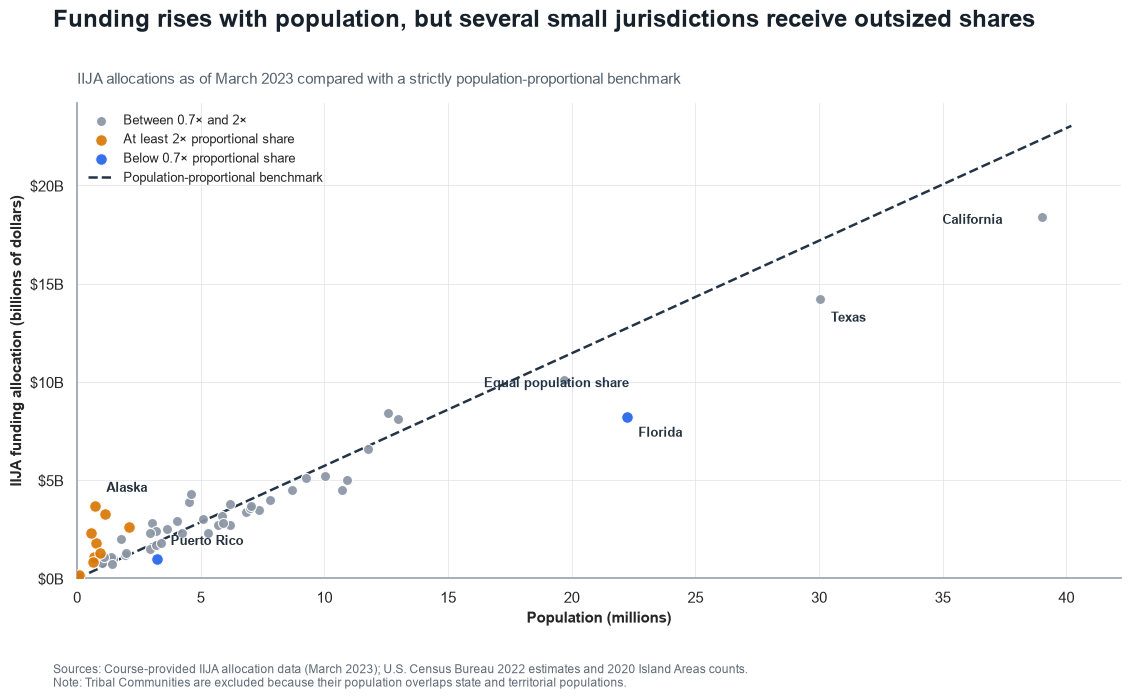

PNG saved to: C:\Users\offcs\GitHub\DATA608-Knowledge-Visual-Analytics\story_01_iija\figures\01_funding_vs_population.png
PDF saved to: C:\Users\offcs\GitHub\DATA608-Knowledge-Visual-Analytics\story_01_iija\figures\01_funding_vs_population.pdf


In [13]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np

# Locate the Story 1 directory regardless of the notebook working directory
current_directory = Path.cwd().resolve()

if (current_directory / "story_01_iija").exists():
    story_directory = current_directory / "story_01_iija"
elif current_directory.name == "story_01_iija":
    story_directory = current_directory
elif current_directory.parent.name == "story_01_iija":
    story_directory = current_directory.parent
else:
    raise FileNotFoundError("Could not locate the story_01_iija directory.")

figures_directory = story_directory / "figures"
figures_directory.mkdir(parents=True, exist_ok=True)

plot_data = analysis.copy()

plot_data["population_millions"] = (
    plot_data["population"] / 1_000_000
)

# Funding billions expected per one million residents
proportional_rate = (
    plot_data["funding_billions"].sum()
    / plot_data["population_millions"].sum()
)

plot_data["equity_category"] = np.select(
    [
        plot_data["allocation_ratio"] >= 2.0,
        plot_data["allocation_ratio"] < 0.70
    ],
    [
        "At least 2× proportional share",
        "Below 0.7× proportional share"
    ],
    default="Between 0.7× and 2×"
)

category_styles = {
    "Between 0.7× and 2×": {
        "color": "#8A94A3",
        "size": 52,
        "zorder": 2
    },
    "At least 2× proportional share": {
        "color": "#D97706",
        "size": 70,
        "zorder": 3
    },
    "Below 0.7× proportional share": {
        "color": "#2563EB",
        "size": 70,
        "zorder": 3
    }
}

fig, ax = plt.subplots(figsize=(12, 7.2))

# Plot jurisdiction groups
for category, style in category_styles.items():
    subset = plot_data.loc[
        plot_data["equity_category"] == category
    ]

    ax.scatter(
        subset["population_millions"],
        subset["funding_billions"],
        s=style["size"],
        color=style["color"],
        edgecolor="white",
        linewidth=0.8,
        alpha=0.92,
        label=category,
        zorder=style["zorder"]
    )

# Strictly population-proportional benchmark
maximum_population = plot_data["population_millions"].max()
benchmark_x = np.linspace(0, maximum_population * 1.03, 200)
benchmark_y = proportional_rate * benchmark_x

ax.plot(
    benchmark_x,
    benchmark_y,
    color="#243447",
    linewidth=1.8,
    linestyle="--",
    label="Population-proportional benchmark",
    zorder=1
)

# Carefully selected labels to avoid clutter
annotation_offsets = {
    "ALASKA": (8, 10),
    "CALIFORNIA": (-72, -5),
    "TEXAS": (8, -16),
    "FLORIDA": (8, -14),
    "PUERTO RICO": (10, 10)
}

for jurisdiction, offset in annotation_offsets.items():
    row = plot_data.loc[
        plot_data["jurisdiction"] == jurisdiction
    ].iloc[0]

    ax.annotate(
        jurisdiction.title(),
        (
            row["population_millions"],
            row["funding_billions"]
        ),
        xytext=offset,
        textcoords="offset points",
        fontsize=9,
        color="#25313C",
        fontweight="semibold"
    )

# Directly label the benchmark
benchmark_label_x = 16
benchmark_label_y = proportional_rate * benchmark_label_x

ax.annotate(
    "Equal population share",
    xy=(benchmark_label_x, benchmark_label_y),
    xytext=(8, 8),
    textcoords="offset points",
    fontsize=9,
    color="#243447",
    fontweight="semibold"
)

# Titles
fig.suptitle(
    "Funding rises with population, but several small jurisdictions receive outsized shares",
    x=0.08,
    y=0.97,
    ha="left",
    fontsize=17,
    fontweight="bold",
    color="#17212B"
)

ax.set_title(
    "IIJA allocations as of March 2023 compared with a strictly population-proportional benchmark",
    loc="left",
    fontsize=11,
    color="#52606D",
    pad=14
)

ax.set_xlabel(
    "Population (millions)",
    fontsize=11,
    fontweight="semibold"
)

ax.set_ylabel(
    "IIJA funding allocation (billions of dollars)",
    fontsize=11,
    fontweight="semibold"
)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"${value:.0f}B")
)

ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

ax.grid(
    axis="both",
    color="#D9DEE5",
    linewidth=0.7,
    alpha=0.65
)

ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#9AA5B1")
ax.spines["bottom"].set_color("#9AA5B1")

ax.legend(
    loc="upper left",
    frameon=False,
    fontsize=9
)

# Source and methodological note
fig.text(
    0.08,
    0.025,
    "Sources: Course-provided IIJA allocation data (March 2023); "
    "U.S. Census Bureau 2022 estimates and 2020 Island Areas counts.\n"
    "Note: Tribal Communities are excluded because their population overlaps "
    "state and territorial populations.",
    ha="left",
    va="bottom",
    fontsize=8.5,
    color="#5F6B76"
)

plt.subplots_adjust(
    left=0.10,
    right=0.97,
    top=0.84,
    bottom=0.18
)

# Save both presentation and publication-quality formats
chart_1_png = figures_directory / "01_funding_vs_population.png"
chart_1_pdf = figures_directory / "01_funding_vs_population.pdf"

fig.savefig(
    chart_1_png,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    chart_1_pdf,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"PNG saved to: {chart_1_png}")
print(f"PDF saved to: {chart_1_pdf}")

## Visualization 2 — Funding per resident

Funding per resident provides a direct comparison after adjusting for jurisdiction
population. The visualization shows the eight highest and eight lowest
allocations using a common scale.

These differences demonstrate that the allocation is not strictly proportional
to population. They do not, by themselves, establish improper or political bias.

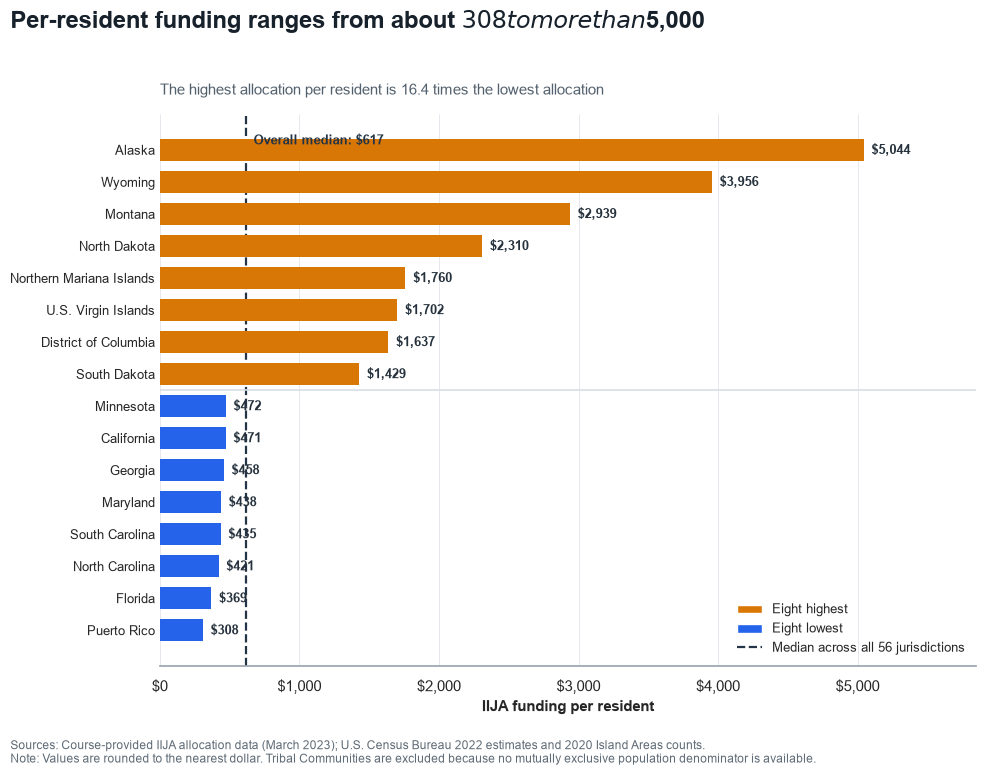

PNG saved to: C:\Users\offcs\GitHub\DATA608-Knowledge-Visual-Analytics\story_01_iija\figures\02_highest_lowest_funding_per_resident.png
PDF saved to: C:\Users\offcs\GitHub\DATA608-Knowledge-Visual-Analytics\story_01_iija\figures\02_highest_lowest_funding_per_resident.pdf


In [14]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Select the eight highest and eight lowest jurisdictions
highest_eight = plot_data.nlargest(
    8, "funding_per_resident"
).copy()

lowest_eight = plot_data.nsmallest(
    8, "funding_per_resident"
).copy()

ranked_extremes = (
    pd.concat([lowest_eight, highest_eight])
    .drop_duplicates(subset="jurisdiction")
    .sort_values("funding_per_resident")
    .reset_index(drop=True)
)

ranked_extremes["group"] = np.where(
    ranked_extremes["jurisdiction"].isin(
        highest_eight["jurisdiction"]
    ),
    "Eight highest",
    "Eight lowest"
)

ranked_extremes["display_name"] = (
    ranked_extremes["jurisdiction"]
    .str.title()
    .replace({
        "Us Virgin Islands": "U.S. Virgin Islands",
        "District Of Columbia": "District of Columbia",
        "Northern Mariana Islands": "Northern Mariana Islands"
    })
)

bar_colors = ranked_extremes["group"].map({
    "Eight highest": "#D97706",
    "Eight lowest": "#2563EB"
})

overall_median = plot_data["funding_per_resident"].median()

fig, ax = plt.subplots(figsize=(11.5, 8))

bars = ax.barh(
    ranked_extremes["display_name"],
    ranked_extremes["funding_per_resident"],
    color=bar_colors,
    height=0.67,
    edgecolor="none"
)

# Value labels
for bar, value in zip(
    bars,
    ranked_extremes["funding_per_resident"]
):
    ax.text(
        value + 55,
        bar.get_y() + bar.get_height() / 2,
        f"${value:,.0f}",
        va="center",
        ha="left",
        fontsize=9,
        color="#25313C",
        fontweight="semibold"
    )

# Overall median benchmark
ax.axvline(
    overall_median,
    color="#243447",
    linestyle="--",
    linewidth=1.6,
    zorder=0
)

ax.text(
    overall_median + 55,
    len(ranked_extremes) - 0.7,
    f"Overall median: ${overall_median:,.0f}",
    fontsize=9,
    color="#243447",
    fontweight="semibold",
    va="center"
)

# Separate the lowest and highest groups
ax.axhline(
    7.5,
    color="#D9DEE5",
    linewidth=1.2
)

fig.suptitle(
    "Per-resident funding ranges from about $308 to more than $5,000",
    x=0.12,
    y=0.97,
    ha="left",
    fontsize=17,
    fontweight="bold",
    color="#17212B"
)

highest_value = highest_eight[
    "funding_per_resident"
].max()

lowest_value = lowest_eight[
    "funding_per_resident"
].min()

range_ratio = highest_value / lowest_value

ax.set_title(
    f"The highest allocation per resident is {range_ratio:.1f} times "
    "the lowest allocation",
    loc="left",
    fontsize=11,
    color="#52606D",
    pad=14
)

ax.set_xlabel(
    "IIJA funding per resident",
    fontsize=11,
    fontweight="semibold"
)

ax.set_ylabel("")

ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"${value:,.0f}"
    )
)

ax.set_xlim(
    0,
    ranked_extremes["funding_per_resident"].max() * 1.16
)

ax.grid(
    axis="x",
    color="#D9DEE5",
    linewidth=0.7,
    alpha=0.7
)

ax.grid(axis="y", visible=False)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#9AA5B1")

ax.tick_params(
    axis="y",
    length=0,
    labelsize=9.5
)

legend_elements = [
    Patch(
        facecolor="#D97706",
        label="Eight highest"
    ),
    Patch(
        facecolor="#2563EB",
        label="Eight lowest"
    ),
    Line2D(
        [0],
        [0],
        color="#243447",
        linestyle="--",
        linewidth=1.6,
        label="Median across all 56 jurisdictions"
    )
]

ax.legend(
    handles=legend_elements,
    loc="lower right",
    frameon=False,
    fontsize=9
)

fig.text(
    0.12,
    0.025,
    "Sources: Course-provided IIJA allocation data (March 2023); "
    "U.S. Census Bureau 2022 estimates and 2020 Island Areas counts.\n"
    "Note: Values are rounded to the nearest dollar. Tribal Communities are "
    "excluded because no mutually exclusive population denominator is available.",
    ha="left",
    va="bottom",
    fontsize=8.5,
    color="#5F6B76"
)

plt.subplots_adjust(
    left=0.25,
    right=0.96,
    top=0.84,
    bottom=0.15
)

chart_2_png = (
    figures_directory
    / "02_highest_lowest_funding_per_resident.png"
)

chart_2_pdf = (
    figures_directory
    / "02_highest_lowest_funding_per_resident.pdf"
)

fig.savefig(
    chart_2_png,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    chart_2_pdf,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"PNG saved to: {chart_2_png}")
print(f"PDF saved to: {chart_2_pdf}")

## Visualization 3 — Allocation by 2020 presidential winner

The population-weighted funding rate compares total funding with the combined
population of jurisdictions won by each candidate.

This descriptive comparison does not show preferential treatment for
Biden-won jurisdictions. Statistical tests also do not establish a significant
difference between the two groups.

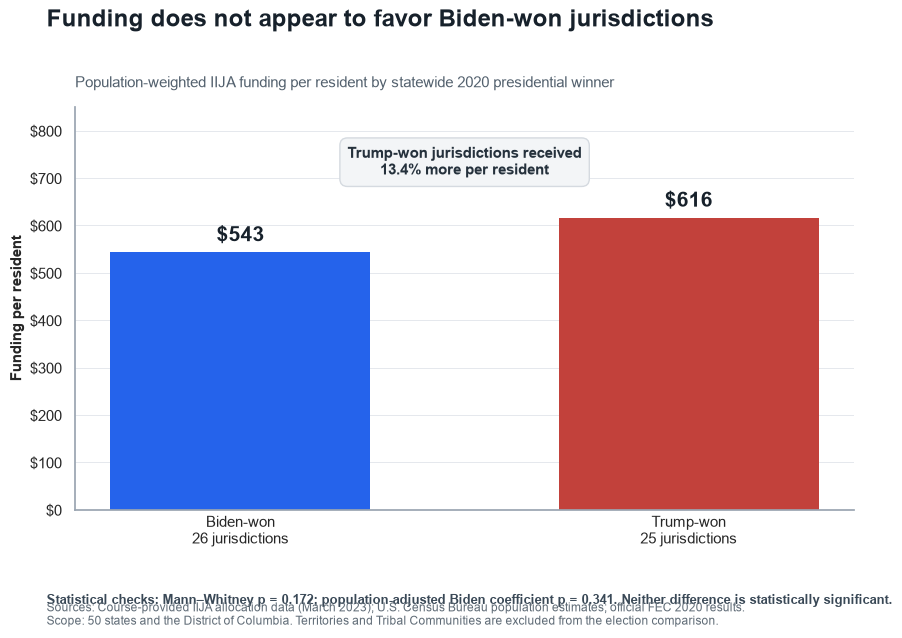

PNG saved to: C:\Users\offcs\GitHub\DATA608-Knowledge-Visual-Analytics\story_01_iija\figures\03_funding_by_2020_winner.png
PDF saved to: C:\Users\offcs\GitHub\DATA608-Knowledge-Visual-Analytics\story_01_iija\figures\03_funding_by_2020_winner.pdf


In [15]:
winner_order = ["Biden", "Trump"]

political_chart_data = (
    political_summary
    .loc[winner_order]
    .copy()
)

weighted_values = political_chart_data[
    "weighted_funding_per_resident"
]

jurisdiction_counts = political_chart_data[
    "jurisdictions"
].astype(int)

bar_labels = [
    f"Biden-won\n{jurisdiction_counts.loc['Biden']} jurisdictions",
    f"Trump-won\n{jurisdiction_counts.loc['Trump']} jurisdictions"
]

fig, ax = plt.subplots(figsize=(9.5, 6.5))

bars = ax.bar(
    bar_labels,
    weighted_values,
    color=["#2563EB", "#C2413B"],
    width=0.58,
    edgecolor="none"
)

# Display exact values
for bar, value in zip(bars, weighted_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 14,
        f"${value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=15,
        fontweight="bold",
        color="#17212B"
    )

difference_percentage = (
    (
        weighted_values.loc["Trump"]
        / weighted_values.loc["Biden"]
    ) - 1
) * 100

# Difference callout
ax.text(
    0.5,
    weighted_values.max() * 1.19,
    f"Trump-won jurisdictions received\n"
    f"{difference_percentage:.1f}% more per resident",
    ha="center",
    va="center",
    fontsize=11,
    fontweight="semibold",
    color="#25313C",
    bbox={
        "boxstyle": "round,pad=0.5",
        "facecolor": "#F3F5F7",
        "edgecolor": "#D5DAE0"
    }
)

fig.suptitle(
    "Funding does not appear to favor Biden-won jurisdictions",
    x=0.11,
    y=0.97,
    ha="left",
    fontsize=17,
    fontweight="bold",
    color="#17212B"
)

ax.set_title(
    "Population-weighted IIJA funding per resident by statewide "
    "2020 presidential winner",
    loc="left",
    fontsize=11,
    color="#52606D",
    pad=14
)

ax.set_ylabel(
    "Funding per resident",
    fontsize=11,
    fontweight="semibold"
)

ax.set_xlabel("")

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"${value:,.0f}"
    )
)

ax.set_ylim(
    0,
    weighted_values.max() * 1.38
)

ax.grid(
    axis="y",
    color="#D9DEE5",
    linewidth=0.7,
    alpha=0.7
)

ax.grid(axis="x", visible=False)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#9AA5B1")
ax.spines["bottom"].set_color("#9AA5B1")

ax.tick_params(
    axis="x",
    length=0,
    labelsize=11
)

fig.text(
    0.11,
    0.055,
    "Statistical checks: Mann–Whitney p = "
    f"{p_value:.3f}; population-adjusted Biden coefficient p = "
    f"{biden_p_value:.3f}. Neither difference is statistically significant.",
    ha="left",
    fontsize=9,
    color="#394856",
    fontweight="semibold"
)

fig.text(
    0.11,
    0.018,
    "Sources: Course-provided IIJA allocation data (March 2023); "
    "U.S. Census Bureau population estimates; official FEC 2020 results.\n"
    "Scope: 50 states and the District of Columbia. Territories and Tribal "
    "Communities are excluded from the election comparison.",
    ha="left",
    va="bottom",
    fontsize=8.3,
    color="#5F6B76"
)

plt.subplots_adjust(
    left=0.14,
    right=0.96,
    top=0.82,
    bottom=0.20
)

chart_3_png = (
    figures_directory
    / "03_funding_by_2020_winner.png"
)

chart_3_pdf = (
    figures_directory
    / "03_funding_by_2020_winner.pdf"
)

fig.savefig(
    chart_3_png,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    chart_3_pdf,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"PNG saved to: {chart_3_png}")
print(f"PDF saved to: {chart_3_pdf}")

## Conclusions

### Population equity

Population is strongly associated with total IIJA funding, but the allocation is
not strictly proportional to population. Several smaller jurisdictions receive
multiple times their population-proportional share, while Puerto Rico, Florida,
and several large states receive substantially less per resident.

Alaska receives approximately $5,044 per resident, compared with approximately
$308 for Puerto Rico—a difference of more than sixteenfold. This establishes
allocation disparity, but it does not by itself establish improper bias. Federal
funding formulas may also reflect minimum allocations, infrastructure needs,
program eligibility, geography, and other factors not included in this analysis.

### Political interests

The available evidence does not indicate that the allocation favored
jurisdictions won by Biden in 2020.

- Biden-won jurisdictions received approximately $543 per resident.
- Trump-won jurisdictions received approximately $616 per resident.
- Trump-won jurisdictions therefore received approximately 13.4% more per
  resident.
- The Mann–Whitney comparison was not statistically significant (p = 0.172).
- After controlling for population, the Biden-winner coefficient also was not
  statistically significant (p = 0.341).

These results provide no persuasive evidence of preferential allocation toward
Biden-won jurisdictions. They do not prove that political considerations played
no role, because this observational analysis cannot establish intent or
causation.

## Limitations

1. Funding reflects announced allocations as of March 2023, not necessarily
   completed expenditures.
2. Most population figures are July 2022 estimates, while four Island Areas use
   official 2020 Census counts.
3. Population alone does not capture infrastructure condition, geographic size,
   rurality, statutory minimums, program eligibility, or project readiness.
4. Statewide 2020 election winners provide a simplified measure of political
   alignment.
5. Territories are included in the equity analysis but excluded from the
   presidential-election comparison.
6. Tribal Communities are reported separately because their populations overlap
   state and territorial populations.

In [16]:
processed_directory = story_directory / "data" / "processed"
sources_directory = story_directory / "sources"

processed_directory.mkdir(parents=True, exist_ok=True)
sources_directory.mkdir(parents=True, exist_ok=True)

geographic_export_columns = [
    "jurisdiction",
    "jurisdiction_type",
    "funding_billions",
    "population",
    "funding_per_resident",
    "population_share",
    "funding_share",
    "expected_funding_billions",
    "allocation_ratio",
    "funding_difference_billions"
]

political_export_columns = [
    "jurisdiction",
    "state_abbreviation",
    "funding_billions",
    "population",
    "funding_per_resident",
    "2020_winner",
    "two_party_margin",
    "biden_indicator"
]

geographic_export = (
    analysis[geographic_export_columns]
    .sort_values("jurisdiction")
)

political_export = (
    political[political_export_columns]
    .sort_values("jurisdiction")
)

political_summary_export = (
    political_summary
    .reset_index()
)

regression_export = (
    regression_results
    .reset_index()
    .rename(columns={"index": "model_term"})
)

geographic_path = (
    processed_directory / "story1_geographic_analysis.csv"
)

political_path = (
    processed_directory / "story1_political_analysis.csv"
)

political_summary_path = (
    processed_directory / "story1_political_summary.csv"
)

regression_path = (
    processed_directory / "story1_regression_results.csv"
)

geographic_export.to_csv(
    geographic_path,
    index=False
)

political_export.to_csv(
    political_path,
    index=False
)

political_summary_export.to_csv(
    political_summary_path,
    index=False
)

regression_export.to_csv(
    regression_path,
    index=False
)

print("Processed files exported:")
print(geographic_path)
print(political_path)
print(political_summary_path)
print(regression_path)

Processed files exported:
C:\Users\offcs\GitHub\DATA608-Knowledge-Visual-Analytics\story_01_iija\data\processed\story1_geographic_analysis.csv
C:\Users\offcs\GitHub\DATA608-Knowledge-Visual-Analytics\story_01_iija\data\processed\story1_political_analysis.csv
C:\Users\offcs\GitHub\DATA608-Knowledge-Visual-Analytics\story_01_iija\data\processed\story1_political_summary.csv
C:\Users\offcs\GitHub\DATA608-Knowledge-Visual-Analytics\story_01_iija\data\processed\story1_regression_results.csv


In [ ]:
sources_text = """# Story 1 Sources

## Infrastructure funding

- Course-provided file: `IIJA FUNDING AS OF MARCH 2023.xlsx`
- Coverage: announced Infrastructure Investment and Jobs Act allocations by
  state, territory, and Tribal Communities as of March 2023.

## Population

- U.S. Census Bureau, Annual Estimates of the Resident Population for the
  United States, Regions, States, District of Columbia, and Puerto Rico:
  April 1, 2020 to July 1, 2022.
- Data file:
  https://www2.census.gov/programs-surveys/popest/tables/2020-2022/state/totals/NST-EST2022-POP.xlsx
- U.S. Census Bureau, 2020 Island Areas population counts:
  https://www.census.gov/newsroom/press-releases/2021/2020-population-us-island-areas.html

## Election results

- Federal Election Commission, Federal Elections 2020:
  https://www.fec.gov/introduction-campaign-finance/election-results-and-voting-information/federal-elections-2020/
- Official results workbook:
  https://www.fec.gov/documents/4228/federalelections2020.xlsx

## Analytical notes

- The population comparison includes 50 states, the District of Columbia,
  Puerto Rico, American Samoa, Guam, Northern Mariana Islands, and the U.S.
  Virgin Islands.
- Tribal Communities are excluded from the per-resident calculations because
  their population overlaps other geographic jurisdictions.
- The political comparison includes only the 50 states and District of Columbia.
"""

ai_disclosure_text = """# AI-Use Disclosure

ChatGPT was used to assist with data-cleaning review, analysis, 
visualization refinement, and editorial review. I reviewed and 
validated all code, calculations, visualizations, interpretations, 
and final conclusions.

"""

sources_file = sources_directory / "SOURCES.md"
ai_disclosure_file = story_directory / "AI_USE_DISCLOSURE.md"

sources_file.write_text(
    sources_text,
    encoding="utf-8"
)

ai_disclosure_file.write_text(
    ai_disclosure_text,
    encoding="utf-8"
)

print(f"Sources saved to: {sources_file}")
print(f"AI disclosure saved to: {ai_disclosure_file}")

Sources saved to: C:\Users\offcs\GitHub\DATA608-Knowledge-Visual-Analytics\story_01_iija\sources\SOURCES.md
AI disclosure saved to: C:\Users\offcs\GitHub\DATA608-Knowledge-Visual-Analytics\story_01_iija\AI_USE_DISCLOSURE.md


In [18]:
original_total = funding["funding_billions"].sum()

geographic_total = analysis[
    "funding_billions"
].sum()

tribal_total = funding.loc[
    funding["jurisdiction_type"] == "Tribal Communities",
    "funding_billions"
].sum()

required_figures = [
    figures_directory / "01_funding_vs_population.png",
    figures_directory / "02_highest_lowest_funding_per_resident.png",
    figures_directory / "03_funding_by_2020_winner.png"
]

required_exports = [
    geographic_path,
    political_path,
    political_summary_path,
    regression_path,
    sources_file,
    ai_disclosure_file
]

assert len(funding) == 57
assert len(analysis) == 56
assert len(political) == 51

assert analysis["population"].notna().all()
assert analysis["funding_per_resident"].notna().all()
assert political["2020_winner"].notna().all()

assert analysis["population"].gt(0).all()
assert analysis["funding_billions"].gt(0).all()

assert np.isclose(
    geographic_total + tribal_total,
    original_total
)

assert np.isclose(
    analysis["population_share"].sum(),
    1.0
)

assert np.isclose(
    analysis["funding_share"].sum(),
    1.0
)

assert all(path.exists() for path in required_figures)
assert all(path.exists() for path in required_exports)

audit_results = pd.Series({
    "Original funding jurisdictions": len(funding),
    "Geographic equity jurisdictions": len(analysis),
    "Political-analysis jurisdictions": len(political),
    "Original funding total (billions)": original_total,
    "Reconciled funding total (billions)": (
        geographic_total + tribal_total
    ),
    "Missing geographic populations": (
        analysis["population"].isna().sum()
    ),
    "Missing election winners": (
        political["2020_winner"].isna().sum()
    ),
    "Required figures saved": sum(
        path.exists() for path in required_figures
    ),
    "Required exports saved": sum(
        path.exists() for path in required_exports
    )
})

print("FINAL AUDIT PASSED")
display(audit_results.to_frame("Result"))

FINAL AUDIT PASSED


,Result
Original funding jurisdictions,57.0000
Geographic equity jurisdictions,56.0000
Political-analysis jurisdictions,51.0000
Original funding total (billions),196.0324
Reconciled funding total (billions),196.0324
Missing geographic populations,0.0000
Missing election winners,0.0000
Required figures saved,3.0000
Required exports saved,6.0000
